# Advanced Iterative Feature Engineering & Incremental Validation Pipelines

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from src import feature_engineering as fe

/Users/hector.vargas/repos/ml_hands_on_project/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Environment Configurations & Partition Loading

In [2]:
X_train = pd.read_csv("../data/processed/raw_features/X_train.csv")
X_val = pd.read_csv("../data/processed/raw_features/X_val.csv")
X_test = pd.read_csv("../data/processed/raw_features/X_test.csv")

y_train = pd.read_csv("../data/processed/target/y_train.csv").squeeze()
y_val = pd.read_csv("../data/processed/target/y_val.csv").squeeze()
y_test = pd.read_csv("../data/processed/target/y_test.csv").squeeze()

In [3]:
# Operational Path Anchors
ROOT_DIR = os.path.abspath("../")
DB_PATH = os.path.join(ROOT_DIR, "mlflow.db")
ARTIFACTS_DIR = os.path.join(ROOT_DIR, "mlartifacts")
EXPERIMENT_NAME = "customer-churn-simple-feature-engineering"

In [4]:
# Schema Baseline Columns Definitions
nomod_columns = [
    'HasCrCard',
    'IsActiveMember'
    ]

dummyfy_columns = [
    'Card Type', 
    'NumOfProducts', 
    'Geography', 
    'Gender'
    ]

norm_std_columns = [
    'Balance', 
    'Point Earned', 
    'CreditScore', 
    'Age', 
    'Tenure', 
    'Satisfaction Score', 
    'EstimatedSalary'
    ]

In [5]:
FEATURE_REGISTRY_BINARY = {
    # --- Binary Flags ---
    "no_balance": lambda X: X["Balance"] < 2500,
    "Num_Of_Products_1": lambda X: X["NumOfProducts"] == 1,
    "Num_Of_Products_2": lambda X: X["NumOfProducts"] == 2,
    "middle_age": lambda X: X["Age"].between(25, 45, inclusive="neither"),
}

FEATURE_REGISTRY_CONTINUOUS = {
    # --- Polynomial & Interaction Terms ---
    "Balance_x_Tenure": lambda X: X["Balance"] * X["Tenure"],
    "Age_x_IsActive": lambda X: X["Age"] * X["IsActiveMember"],

    # --- Financial & Engagement Ratios ---
    "Balance_to_Salary": lambda X: X["Balance"] / (X["EstimatedSalary"] + 1),
    "Balance_per_Product": lambda X: X["Balance"] / (X["NumOfProducts"] + 1),
    "Salary_per_Product": lambda X: X["EstimatedSalary"] / (X["NumOfProducts"] + 1),
    "CreditScore_per_Age": lambda X: X["CreditScore"] / (X["Age"] + 1),
    "Tenure_per_Age": lambda X: X["Tenure"] / (X["Age"] + 1),

    # --- Behavioral Cross-Products ---
    "Inactive_x_Balance": lambda X: (1 - X["IsActiveMember"]) * X["Balance"],
    "Inactive_x_Age": lambda X: (1 - X["IsActiveMember"]) * X["Age"],
    "Products_x_Active": lambda X: X["NumOfProducts"] * X["IsActiveMember"],

    # --- Monetary Accumulations & Non-linear Scaling ---
    "Balance_plus_Salary": lambda X: X["Balance"] + X["EstimatedSalary"],
    "WealthScore": lambda X: 0.6 * X["Balance"] + 0.4 * X["EstimatedSalary"],
    "CreditScore_x_Age": lambda X: X["CreditScore"] * X["Age"],
    "LogBalance": lambda X: np.log1p(X["Balance"]),
    "LogAge": lambda X: np.log1p(X["Age"]),

    # --- Polynomial Degrees ---
    "Age2": lambda X: X["Age"] ** 2,
    "Balance2": lambda X: X["Balance"] ** 2,
    "Tenure2": lambda X: X["Tenure"] ** 2,

    # --- Temporal Product Densities ---
    "Products_per_Tenure": lambda X: X["NumOfProducts"] / (X["Tenure"] + 1),
    "Balance_per_Tenure": lambda X: X["Balance"] / (X["Tenure"] + 1),
}

In [6]:
all_engineered_features = list(FEATURE_REGISTRY_BINARY.keys())

EXPERIMENT_REGISTRY = {
    # Experiment 1: 
    "experiment_1": {
        "passthrough": nomod_columns + list(FEATURE_REGISTRY_BINARY.keys()),
        "standard_scale": norm_std_columns + list(FEATURE_REGISTRY_CONTINUOUS.keys()),
        "one_hot_encode": dummyfy_columns
    },
}

## 2. Global Multi-Model Experiment Log Execution

In [7]:
fe.init_mlflow_experiment(EXPERIMENT_NAME, DB_PATH, ARTIFACTS_DIR)

In [8]:
# Combine registries purely for execution lookup inside the transformer
FULL_REGISTRY = {**FEATURE_REGISTRY_BINARY, **FEATURE_REGISTRY_CONTINUOUS}

models_zoo = {
    "random_forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "xgboost": XGBClassifier(random_state=42, n_jobs=-1, eval_metric="aucpr")
}

In [13]:
FEATURE_REGISTRY_BINARY = {
    # --- Binary Flags ---
    "no_balance": lambda X: X["Balance"] < 2500,
    "Num_Of_Products_1": lambda X: X["NumOfProducts"] == 1,
    "Num_Of_Products_2": lambda X: X["NumOfProducts"] == 2,
    "is_germany": lambda X: X["Geography"] == 'Germany',
    "is_spain": lambda X: X["Geography"] == 'Spain',
    "is_france": lambda X: X["Geography"] == 'France',
    "middle_age": lambda X: X["Age"].between(25, 45, inclusive="neither"),
}

FEATURE_REGISTRY_CONTINUOUS = {
    # --- Polynomial & Interaction Terms ---
    "Balance_x_Tenure": lambda X: X["Balance"] * X["Tenure"],
    "Age_x_IsActive": lambda X: X["Age"] * X["IsActiveMember"],

    # --- Financial & Engagement Ratios ---
    "Balance_to_Salary": lambda X: X["Balance"] / (X["EstimatedSalary"] + 1),
    "Balance_per_Product": lambda X: X["Balance"] / (X["NumOfProducts"] + 1),
    "Salary_per_Product": lambda X: X["EstimatedSalary"] / (X["NumOfProducts"] + 1),
    "CreditScore_per_Age": lambda X: X["CreditScore"] / (X["Age"] + 1),
    "Tenure_per_Age": lambda X: X["Tenure"] / (X["Age"] + 1),

    # --- Behavioral Cross-Products ---
    "Inactive_x_Balance": lambda X: (1 - X["IsActiveMember"]) * X["Balance"],
    "Inactive_x_Age": lambda X: (1 - X["IsActiveMember"]) * X["Age"],
    "Products_x_Active": lambda X: X["NumOfProducts"] * X["IsActiveMember"],

    # --- Monetary Accumulations & Non-linear Scaling ---
    "Balance_plus_Salary": lambda X: X["Balance"] + X["EstimatedSalary"],
    "WealthScore": lambda X: 0.6 * X["Balance"] + 0.4 * X["EstimatedSalary"],
    "CreditScore_x_Age": lambda X: X["CreditScore"] * X["Age"],
    "LogBalance": lambda X: np.log1p(X["Balance"]),
    "LogAge": lambda X: np.log1p(X["Age"]),

    # --- Polynomial Degrees ---
    "Age2": lambda X: X["Age"] ** 2,
    "Balance2": lambda X: X["Balance"] ** 2,
    "Tenure2": lambda X: X["Tenure"] ** 2,

    # --- Temporal Product Densities ---
    "Products_per_Tenure": lambda X: X["NumOfProducts"] / (X["Tenure"] + 1),
    "Balance_per_Tenure": lambda X: X["Balance"] / (X["Tenure"] + 1),
}
# Schema Baseline Columns Definitions
nomod_columns = [
    'HasCrCard',
    'IsActiveMember'
    ]

dummyfy_columns = [
    'Card Type',
    'Gender'
    ]

norm_std_columns = [
    'Balance', 
    'Point Earned', 
    'CreditScore', 
    'Age', 
    'Tenure', 
    'Satisfaction Score', 
    'EstimatedSalary'
    ]

In [14]:
# Select your experiment configuration layout mapping
layout = EXPERIMENT_REGISTRY["experiment_1"]

# Define your parameter spaces
search_directions = {
    "Forward": True,
    "Backward": False
}

# Master list to collect every single iteration result
all_loop_results = []

# --- Comprehensive Sweep: Models x Directions x Feature Counts ---
for model_name, model_obj in models_zoo.items():
    for direction_label, is_forward in search_directions.items():
        print(f"\n" + "="*60)
        print(f"RUNNING GRID: {model_name.upper()} ({direction_label.upper()})")
        print("="*60)
        
        for target_features in range(5, 28):
            print(f"\n -> Evaluating subset size: {target_features} features...")
            
            # Call your sequential selection function over the explicit integer count
            sfs_obj, _ = fe.run_sequential_selection(
                X=X_train,
                y=y_train,
                routing_config=layout,
                base_model=model_obj,
                forward=is_forward,
                k_features=target_features,
                FULL_REGISTRY=FULL_REGISTRY
            )
            
            # Log the granular data for this specific row step
            all_loop_results.append({
                "model": model_name,
                "direction": direction_label,
                "n_features": target_features,
                "pr_auc_cv": sfs_obj.k_score_,
                "features": sorted(list(sfs_obj.k_feature_names_))
            })

# =====================================================================
# ANALYZE THE SWEEP DATA
# =====================================================================
# Convert the massive results cache into a single unified tracking table
comprehensive_results_df = pd.DataFrame(all_loop_results)

# 1. View the absolute best configurations sorted by PR-AUC
sorted_top_df = comprehensive_results_df.sort_values(by="pr_auc_cv", ascending=False).reset_index(drop=True)
print("\n### Top Performing Grid Combinations:")
display(sorted_top_df.head(10))


RUNNING GRID: RANDOM_FOREST (FORWARD)

 -> Evaluating subset size: 5 features...

--- Running Forward Feature Selection on RandomForestClassifier ---
Optimal Feature Subset Size: 5
Optimal Feature Names: ('cat__NumOfProducts_2', 'num__Inactive_x_Age', 'num__Products_x_Active', 'num__Age2', 'pass__Num_Of_Products_1')
Best CV Score (PR-AUC): 0.6270

 -> Evaluating subset size: 6 features...

--- Running Forward Feature Selection on RandomForestClassifier ---
Optimal Feature Subset Size: 6
Optimal Feature Names: ('cat__NumOfProducts_2', 'num__Inactive_x_Age', 'num__Products_x_Active', 'num__Age2', 'pass__Num_Of_Products_1', 'pass__Num_Of_Products_2')
Best CV Score (PR-AUC): 0.6277

 -> Evaluating subset size: 7 features...

--- Running Forward Feature Selection on RandomForestClassifier ---
Optimal Feature Subset Size: 7
Optimal Feature Names: ('cat__NumOfProducts_2', 'num__Age_x_IsActive', 'num__Inactive_x_Age', 'num__Products_x_Active', 'num__Age2', 'pass__Num_Of_Products_1', 'pass__Nu

/Users/hector.vargas/repos/ml_hands_on_project/env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/hector.vargas/repos/ml_hands_on_project/env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/hector.vargas/repos/ml_hands_on_project/env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

Optimal Feature Subset Size: 13
Optimal Feature Names: ('cat__NumOfProducts_2', 'cat__NumOfProducts_3', 'cat__NumOfProducts_4', 'num__Age', 'num__Age_x_IsActive', 'num__Inactive_x_Age', 'num__Products_x_Active', 'num__LogAge', 'num__Age2', 'pass__IsActiveMember', 'pass__Num_Of_Products_1', 'pass__Num_Of_Products_2', 'pass__middle_age')
Best CV Score (PR-AUC): 0.6254

 -> Evaluating subset size: 14 features...

--- Running Forward Feature Selection on RandomForestClassifier ---
Optimal Feature Subset Size: 14
Optimal Feature Names: ('cat__NumOfProducts_2', 'cat__NumOfProducts_3', 'cat__NumOfProducts_4', 'cat__Geography_Germany', 'num__Age', 'num__Age_x_IsActive', 'num__Inactive_x_Age', 'num__Products_x_Active', 'num__LogAge', 'num__Age2', 'pass__IsActiveMember', 'pass__Num_Of_Products_1', 'pass__Num_Of_Products_2', 'pass__middle_age')
Best CV Score (PR-AUC): 0.6239

 -> Evaluating subset size: 15 features...

--- Running Forward Feature Selection on RandomForestClassifier ---
Optimal Fe

/Users/hector.vargas/repos/ml_hands_on_project/env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/hector.vargas/repos/ml_hands_on_project/env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/hector.vargas/repos/ml_hands_on_project/env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

Optimal Feature Subset Size: 26
Optimal Feature Names: ('cat__Card Type_GOLD', 'cat__Card Type_PLATINUM', 'cat__NumOfProducts_2', 'cat__NumOfProducts_3', 'cat__NumOfProducts_4', 'cat__Geography_Germany', 'cat__Geography_Spain', 'cat__Gender_Male', 'num__Point Earned', 'num__Age', 'num__Age_x_IsActive', 'num__Balance_to_Salary', 'num__Salary_per_Product', 'num__Inactive_x_Age', 'num__Products_x_Active', 'num__WealthScore', 'num__CreditScore_x_Age', 'num__LogBalance', 'num__LogAge', 'num__Age2', 'num__Balance_per_Tenure', 'pass__IsActiveMember', 'pass__no_balance', 'pass__Num_Of_Products_1', 'pass__Num_Of_Products_2', 'pass__middle_age')
Best CV Score (PR-AUC): 0.6656

 -> Evaluating subset size: 27 features...

--- Running Forward Feature Selection on RandomForestClassifier ---
Optimal Feature Subset Size: 27
Optimal Feature Names: ('cat__Card Type_GOLD', 'cat__Card Type_PLATINUM', 'cat__NumOfProducts_2', 'cat__NumOfProducts_3', 'cat__NumOfProducts_4', 'cat__Geography_Germany', 'cat__Ge

...

/Users/hector.vargas/repos/ml_hands_on_project/env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/hector.vargas/repos/ml_hands_on_project/env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/hector.vargas/repos/ml_hands_on_project/env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

Optimal Feature Subset Size: 22
Optimal Feature Names: ('cat__Card Type_PLATINUM', 'cat__Card Type_SILVER', 'cat__NumOfProducts_2', 'cat__NumOfProducts_3', 'cat__NumOfProducts_4', 'cat__Geography_Germany', 'cat__Geography_Spain', 'cat__Gender_Male', 'num__Point Earned', 'num__Tenure', 'num__Satisfaction Score', 'num__EstimatedSalary', 'num__Balance_x_Tenure', 'num__Age_x_IsActive', 'num__Balance_per_Product', 'num__CreditScore_per_Age', 'num__Inactive_x_Balance', 'num__CreditScore_x_Age', 'num__Products_per_Tenure', 'num__Balance_per_Tenure', 'pass__Num_Of_Products_1', 'pass__Num_Of_Products_2')
Best CV Score (PR-AUC): 0.6728

 -> Evaluating subset size: 23 features...

--- Running Backward Feature Selection on RandomForestClassifier ---
Optimal Feature Subset Size: 23
Optimal Feature Names: ('cat__Card Type_GOLD', 'cat__Card Type_PLATINUM', 'cat__Card Type_SILVER', 'cat__NumOfProducts_2', 'cat__NumOfProducts_3', 'cat__NumOfProducts_4', 'cat__Geography_Germany', 'cat__Geography_Spain',

/Users/hector.vargas/repos/ml_hands_on_project/env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Optimal Feature Subset Size: 26
Optimal Feature Names: ('cat__Card Type_GOLD', 'cat__Card Type_PLATINUM', 'cat__Card Type_SILVER', 'cat__NumOfProducts_2', 'cat__NumOfProducts_3', 'cat__NumOfProducts_4', 'cat__Geography_Germany', 'cat__Geography_Spain', 'cat__Gender_Male', 'num__Point Earned', 'num__Tenure', 'num__Satisfaction Score', 'num__EstimatedSalary', 'num__Balance_x_Tenure', 'num__Age_x_IsActive', 'num__Balance_to_Salary', 'num__Balance_per_Product', 'num__Salary_per_Product', 'num__CreditScore_per_Age', 'num__Inactive_x_Balance', 'num__CreditScore_x_Age', 'num__Products_per_Tenure', 'num__Balance_per_Tenure', 'pass__no_balance', 'pass__Num_Of_Products_1', 'pass__Num_Of_Products_2')
Best CV Score (PR-AUC): 0.6675

 -> Evaluating subset size: 27 features...

--- Running Backward Feature Selection on RandomForestClassifier ---
Optimal Feature Subset Size: 27
Optimal Feature Names: ('cat__Card Type_GOLD', 'cat__Card Type_PLATINUM', 'cat__Card Type_SILVER', 'cat__NumOfProducts_2', '

,model,direction,n_features,pr_auc_cv,features
0,random_forest,Backward,17,0.674165,"[cat__Card Type_SILVER, cat__Gender_Male, cat_..."
1,random_forest,Backward,22,0.672782,"[cat__Card Type_PLATINUM, cat__Card Type_SILVE..."
2,random_forest,Backward,18,0.671262,"[cat__Card Type_SILVER, cat__Gender_Male, cat_..."
3,random_forest,Backward,27,0.671085,"[cat__Card Type_GOLD, cat__Card Type_PLATINUM,..."
4,random_forest,Backward,19,0.670840,"[cat__Card Type_SILVER, cat__Gender_Male, cat_..."
5,random_forest,Backward,24,0.670422,"[cat__Card Type_GOLD, cat__Card Type_PLATINUM,..."
6,random_forest,Backward,20,0.669974,"[cat__Card Type_SILVER, cat__Gender_Male, cat_..."
7,random_forest,Backward,23,0.669914,"[cat__Card Type_GOLD, cat__Card Type_PLATINUM,..."
8,random_forest,Backward,14,0.669587,"[cat__Card Type_SILVER, cat__Geography_Germany..."
9,random_forest,Backward,16,0.669174,"[cat__Card Type_SILVER, cat__Gender_Male, cat_..."


In [15]:
# Create a pivot table showing the performance curve from 5 to 16 features
performance_curves = comprehensive_results_df.pivot(
    index="n_features", 
    columns=["model", "direction"], 
    values="pr_auc_cv"
)

print("\n### PR-AUC Curves Across Feature Quantities:")
display(performance_curves)


### PR-AUC Curves Across Feature Quantities:


model      random_forest             xgboost          
direction        Forward  Backward   Forward  Backward
n_features                                            
5               0.626960  0.565931  0.633767  0.637450
6               0.627744  0.603756  0.650186  0.650125
7               0.628250  0.637282  0.666513  0.655448
8               0.627720  0.645276  0.666513  0.659881
9               0.627037  0.655101  0.666513  0.657286
10              0.626818  0.657473  0.666513  0.657113
11              0.627584  0.662827  0.665966  0.656600
12              0.627345  0.662148  0.667821  0.663898
13              0.625423  0.664622  0.667811  0.664153
14              0.623891  0.669587  0.667541  0.665113
15              0.626569  0.668164  0.665868  0.666311
16              0.609202  0.669174  0.665571  0.668776
17              0.600911  0.674165  0.659532  0.663145
18              0.630107  0.671262  0.653628  0.666575
19              0.647682  0.670840  0.653877  0.666365
20              0.655781  0.669974  0.657372  0.665733
21              0.658768  0.668661  0.657918  0.661792
22              0.660407  0.672782  0.661542  0.661154
23              0.662464  0.669914  0.666089  0.664972
24              0.664185  0.670422  0.666447  0.665331
25              0.664358  0.668863  0.666447  0.666973
26              0.665603  0.667472  0.665653  0.669153
27              0.665118  0.671085  0.664519  0.667929

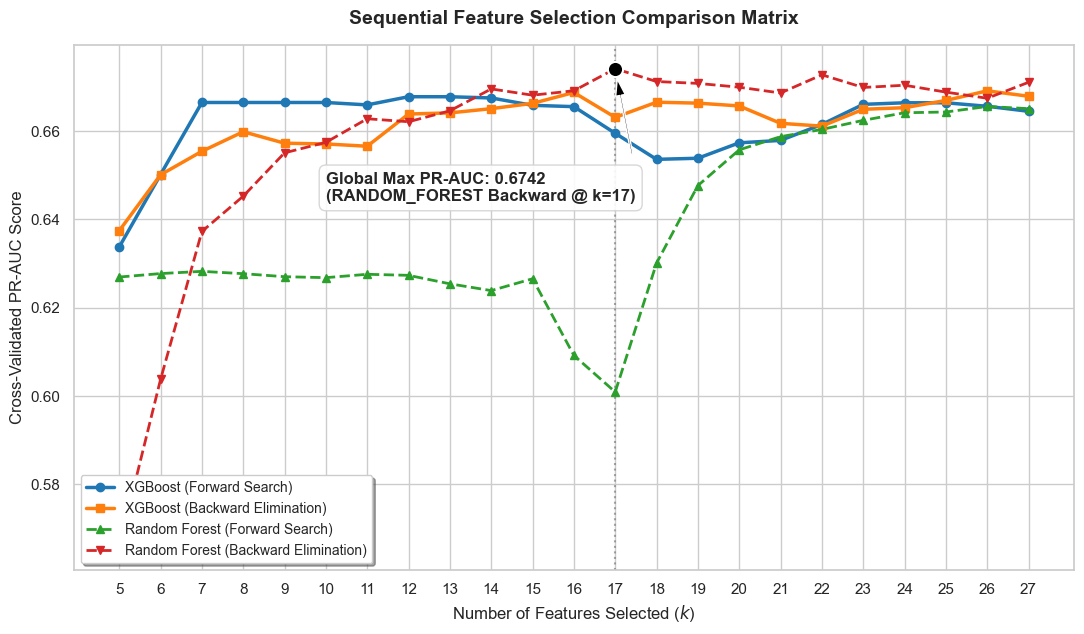

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6.5))

# --- PLOT ENTIRE MODEL HYPOTHESIS SPACE ---

# XGBoost Curves (Solid lines)
plt.plot(
    performance_curves.index, 
    performance_curves[("xgboost", "Forward")], 
    marker='o', linestyle='-', linewidth=2.5, 
    color='#1f77b4', label='XGBoost (Forward Search)'
)
plt.plot(
    performance_curves.index, 
    performance_curves[("xgboost", "Backward")], 
    marker='s', linestyle='-', linewidth=2.5, 
    color='#ff7f0e', label='XGBoost (Backward Elimination)'
)

# Random Forest Curves (Dashed lines to group by model architecture easily)
plt.plot(
    performance_curves.index, 
    performance_curves[("random_forest", "Forward")], 
    marker='^', linestyle='--', linewidth=2.0, 
    color='#2ca02c', label='Random Forest (Forward Search)'
)
plt.plot(
    performance_curves.index, 
    performance_curves[("random_forest", "Backward")], 
    marker='v', linestyle='--', linewidth=2.0, 
    color='#d62728', label='Random Forest (Backward Elimination)'
)

# --- CHART AESTHETICS & CUSTOMIZATION ---
plt.title("Sequential Feature Selection Comparison Matrix", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Number of Features Selected ($k$)", fontsize=12)
plt.ylabel("Cross-Validated PR-AUC Score", fontsize=12)
plt.xticks(performance_curves.index)

# --- DYNAMIC GLOBAL PEAK HIGHLIGHT ---
# Extracting the absolute highest point achieved across all 4 curves
best_model = "random_forest"
best_dir = "Backward"
best_k = 17
best_score = performance_curves[(best_model, best_dir)].max()

# Draw marker point elements
plt.axvline(x=best_k, color='#7f7f7f', linestyle=':', alpha=0.7, zorder=1)
plt.scatter(best_k, best_score, color='black', s=120, edgecolors='white', linewidths=1.5, zorder=5)

# Place text callout dynamically balanced in upper left
plt.annotate(
    f"Global Max PR-AUC: {best_score:.4f}\n({best_model.upper()} {best_dir} @ k={best_k})", 
    xy=(best_k, best_score), 
    xytext=(best_k - 7., best_score - 0.03),
    arrowprops=dict(facecolor='black', shrink=0.1, width=1.2, headwidth=7),
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.4", fc="#ffffff", ec="#d3d3d3", alpha=0.9)
)

# Place legend cleanly without overlapping data curves
plt.legend(fontsize=10, loc="lower left", frameon=True, shadow=True)
plt.tight_layout()
plt.show()

In [25]:
comprehensive_results_df.loc[
    comprehensive_results_df['pr_auc_cv'].idxmax(),
    'features'
]

['cat__Card Type_SILVER',
 'cat__Gender_Male',
 'cat__Geography_Germany',
 'cat__Geography_Spain',
 'cat__NumOfProducts_3',
 'cat__NumOfProducts_4',
 'num__Age_x_IsActive',
 'num__Balance_per_Product',
 'num__CreditScore_per_Age',
 'num__CreditScore_x_Age',
 'num__EstimatedSalary',
 'num__Inactive_x_Balance',
 'num__Point Earned',
 'num__Products_per_Tenure',
 'num__Satisfaction Score',
 'pass__Num_Of_Products_1',
 'pass__Num_Of_Products_2']

In [ ]:
FEATURE_REGISTRY_BINARY = {
    # --- Binary Flags ---
    "is_silver": lambda X: X["Card Type"] == 'SILVER',
    "is_germany": lambda X: X["Geography"] == 'Germany',
    "is_spain": lambda X: X["Geography"] == 'Spain',
    "Num_Of_Products_1": lambda X: X["NumOfProducts"] == 1,
    "Num_Of_Products_2": lambda X: X["NumOfProducts"] == 2,
    "Num_Of_Products_3": lambda X: X["NumOfProducts"] == 3,
    "Num_Of_Products_4": lambda X: X["NumOfProducts"] == 4,
}

FEATURE_REGISTRY_CONTINUOUS = {
    # --- Polynomial & Interaction Terms ---
    "Age_x_IsActive": lambda X: X["Age"] * X["IsActiveMember"],

    # --- Financial & Engagement Ratios ---
    "Balance_per_Product": lambda X: X["Balance"] / (X["NumOfProducts"] + 1),
    "CreditScore_per_Age": lambda X: X["CreditScore"] / (X["Age"] + 1),

    # --- Behavioral Cross-Products ---
    "Inactive_x_Balance": lambda X: (1 - X["IsActiveMember"]) * X["Balance"],

    # --- Monetary Accumulations & Non-linear Scaling ---
    "CreditScore_x_Age": lambda X: X["CreditScore"] * X["Age"],

    # --- Temporal Product Densities ---
    "Products_per_Tenure": lambda X: X["NumOfProducts"] / (X["Tenure"] + 1),
}
# Schema Baseline Columns Definitions
nomod_columns = []

dummyfy_columns = [
    'Gender'
    ]

norm_std_columns = [
    'Point Earned',
    'Satisfaction Score', 
    'EstimatedSalary'
    ]